In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("D:\main_projects\heart.csv")

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Rahul\AppData\Local\Temp\ipykernel_19536\976934735.py:1: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv("D:\main_projects\heart.csv")


### Before moving to data

In [8]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [9]:
df.columns =  df.columns.str.lower()

# Phase 1 :  Understanding the data

In [10]:
df.head()

,age,sex,chestpaintype,restingbp,cholesterol,fastingbs,restingecg,maxhr,exerciseangina,oldpeak,st_slope,heartdisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [11]:
df.shape

(918, 12)

In [12]:
df.isnull().sum()

age               0
sex               0
chestpaintype     0
restingbp         0
cholesterol       0
fastingbs         0
restingecg        0
maxhr             0
exerciseangina    0
oldpeak           0
st_slope          0
heartdisease      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

age                 int64
sex                object
chestpaintype      object
restingbp           int64
cholesterol         int64
fastingbs           int64
restingecg         object
maxhr               int64
exerciseangina     object
oldpeak           float64
st_slope           object
heartdisease        int64
dtype: object

In [15]:
df.describe()

,age,restingbp,cholesterol,fastingbs,maxhr,oldpeak,heartdisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Phase 1 summary: 
### Dataset Overview
#### The dataset contains 918 observations and 12 features
#### Each row represents a patient record with clinical attributes related to cardiovascular health
#### The dataset is structured for a binary classification task
### Data Quality Assessment
#### Missing Values: No missing values detected across all features
#### Duplicate Records: No duplicate entries found
#### Data Types: All columns have appropriate data types (numerical/categorical as expected)
#### Data Consistency: No obvious inconsistencies or invalid entries observed


# Phase 2 : EDA (Exploratory Data Analysis)

### Target Veriable Analysis

In [16]:
df['heartdisease'].unique() 

array([0, 1])

#### Here 0 represents  → No heart disease
#### and  1 → Presence of heart disease

In [17]:
df['heartdisease'].value_counts()

heartdisease
1    508
0    410
Name: count, dtype: int64

#### The target variable shows a slight class imbalance, with approximately 55% positive cases and 45% negative cases. However, the imbalance is not severe enough to significantly impact model performance.

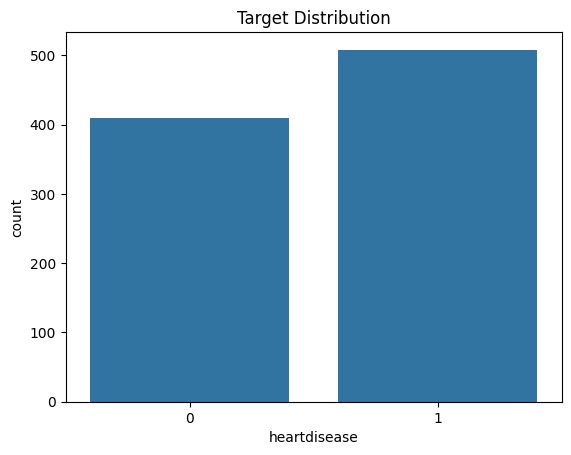

In [18]:
sns.countplot(x = 'heartdisease' , data = df)
plt.title('Target Distribution')
plt.show()

### Univariate Analysis

#### Numeric Features

In [19]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'restingbp'}>,
        <Axes: title={'center': 'cholesterol'}>],
       [<Axes: title={'center': 'fastingbs'}>,
        <Axes: title={'center': 'maxhr'}>,
        <Axes: title={'center': 'oldpeak'}>],
       [<Axes: title={'center': 'heartdisease'}>, <Axes: >, <Axes: >]],
      dtype=object)

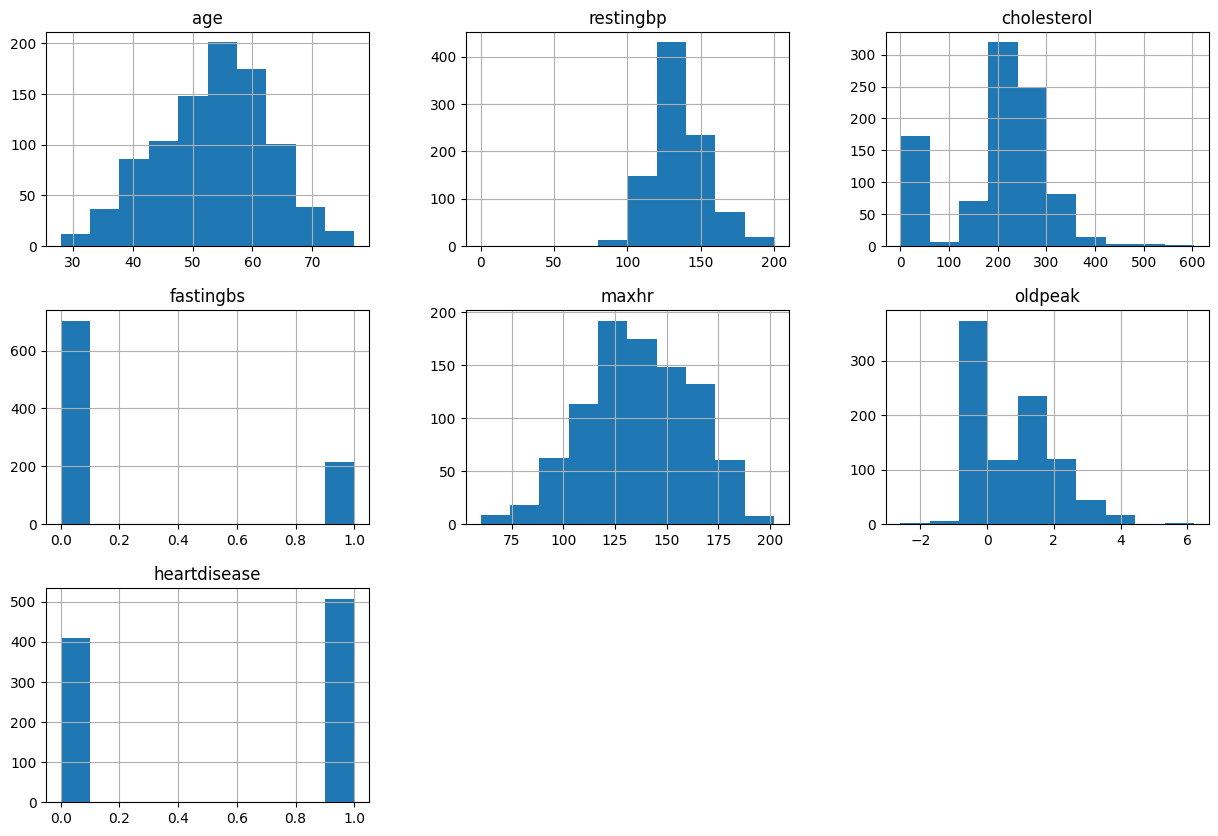

In [20]:
df[num_cols].hist(figsize=(15,10))

#### Observation Features such as age and maxhr exhibit approximately normal distributions, making them suitable for standard modeling techniques
#### Variables like cholesterol and oldpeak show significant right skewness and potential outliers
#### The presence of zero values in cholesterol suggests possible data quality issues or missing value encoding
#### fastingbs is a binary variable with strong class imbalance, indicating limited variability
#### Some features may require scaling and outlier handling before model training


<Axes: xlabel='heartdisease', ylabel='cholesterol'>

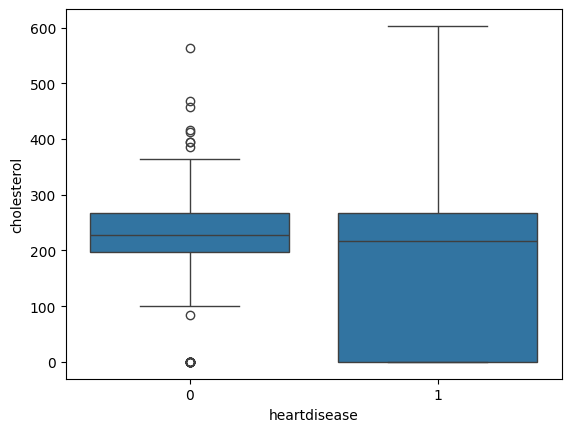

In [21]:
sns.boxplot(x='heartdisease', y='cholesterol', data=df)

<Axes: xlabel='heartdisease', ylabel='maxhr'>

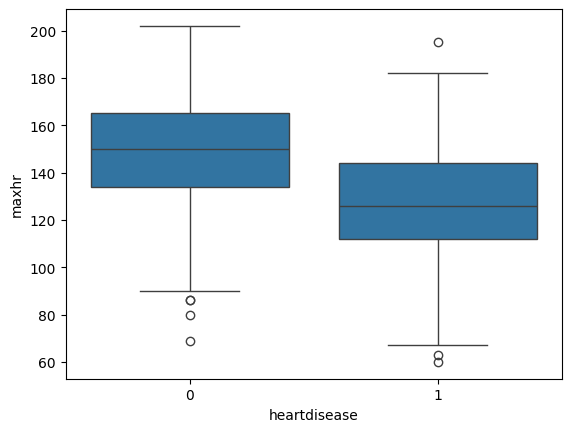

In [22]:
sns.boxplot(x='heartdisease', y='maxhr', data=df)


<Axes: xlabel='heartdisease', ylabel='oldpeak'>

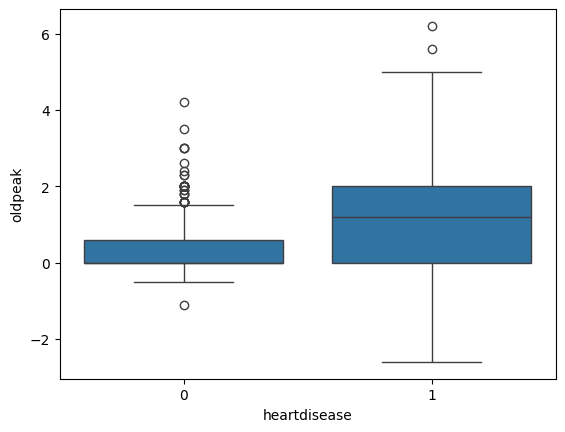

In [23]:
sns.boxplot(x='heartdisease', y='oldpeak', data=df)

### Overservation:
#### Max Heart Rate (maxhr) shows a strong inverse relationship with heart disease, where affected patients tend to have lower maximum heart rates
#### Oldpeak demonstrates a clear positive association with heart disease, with higher values observed in affected individuals
#### Both features exhibit clear class separability, indicating high predictive potential
#### These variables are expected to play a significant role in model performance

## Phase 3 : Feature Engineering

#### Cholesterol Column

In [24]:
(df['cholesterol'] == 0).sum()

np.int64(172)

In [25]:
df['cholesterol'].describe()

count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: cholesterol, dtype: float64

#### Approximately 18.7% of the cholesterol values are recorded as zero, which is not physiologically valid and indicates implicit missing data. This significantly distorts the distribution, as reflected by the gap between mean and median values. Therefore, these zero values must be treated as missing and handled appropriately before modeling.

In [26]:
df['cholesterol'] = df['cholesterol'].replace(0, np.nan)

df['cholesterol'] = df.groupby('heartdisease')['cholesterol']\
                      .transform(lambda x: x.fillna(x.median()))

In [27]:
df.head(2)

,age,sex,chestpaintype,restingbp,cholesterol,fastingbs,restingecg,maxhr,exerciseangina,oldpeak,st_slope,heartdisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1


## Phase 4 : Model Training

In [28]:
num_cols = ['age','restingbp', 'cholesterol','maxhr','oldpeak']
cat_cols = ['sex', 'chestpaintype', 'restingecg', 
            'exerciseangina', 'st_slope', 'fastingbs']

#### Creating Pipeline

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [30]:
# Numeric Pipeline
num_pipeline = Pipeline([
    ('scaler',StandardScaler())
])

# Categorical Pipeline

cat_pipeline = Pipeline([
    ('encoder',OneHotEncoder(drop='first'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


#### Full Pipeline

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [32]:
from sklearn.model_selection import train_test_split

X = df.drop('heartdisease', axis=1)
y = df['heartdisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Training Model

In [33]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8913043478260869
Precision: 0.8942307692307693
Recall: 0.9117647058823529
F1 Score: 0.9029126213592233
ROC-AUC: 0.9350789096126254


### Logistic Regression Performance Summary:
#### The Logistic Regression model achieved strong performance with an accuracy of 89.1% and an ROC-AUC score of 0.93, indicating excellent class separability. The recall of 91.17% is particularly important in this healthcare context, as it reflects the model's ability to correctly identify patients with heart disease. The balance between precision and recall suggests that the model performs reliably without excessive false positives.

In [35]:
import pandas as pd

feature_names = model.named_steps['preprocessing'].get_feature_names_out()
coefficients = model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)


In [36]:
top_positive = coef_df.head(5)
top_positive

,Feature,Coefficient
5,cat__sex_M,1.311632
14,cat__fastingbs_1,1.158563
12,cat__st_slope_Flat,0.902804
11,cat__exerciseangina_Y,0.836738
4,num__oldpeak,0.255468


In [37]:
top_negative = coef_df.tail(5)
top_negative

,Feature,Coefficient
3,num__maxhr,-0.305477
8,cat__chestpaintype_TA,-1.111378
13,cat__st_slope_Up,-1.394673
6,cat__chestpaintype_ATA,-1.526399
7,cat__chestpaintype_NAP,-1.573940


In [38]:
print("Top 5 Positive Features:")
print(top_positive)

print("\nTop 5 Negative Features:")
print(top_negative)

Top 5 Positive Features:
                  Feature  Coefficient
5              cat__sex_M     1.311632
14       cat__fastingbs_1     1.158563
12     cat__st_slope_Flat     0.902804
11  cat__exerciseangina_Y     0.836738
4            num__oldpeak     0.255468

Top 5 Negative Features:
                   Feature  Coefficient
3               num__maxhr    -0.305477
8    cat__chestpaintype_TA    -1.111378
13        cat__st_slope_Up    -1.394673
6   cat__chestpaintype_ATA    -1.526399
7   cat__chestpaintype_NAP    -1.573940


### The model coefficients indicate that features such as male gender, elevated fasting blood sugar, flat ST slope, exercise-induced angina, and higher oldpeak values significantly increase the likelihood of heart disease. Conversely, higher maximum heart rate and certain chest pain types are associated with reduced risk. These findings align closely with domain knowledge and earlier exploratory data analysis, reinforcing the reliability of the model.

## Rainforest Pipeline

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [41]:
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8695652173913043
Precision: 0.8823529411764706
Recall: 0.8823529411764706
F1 Score: 0.8823529411764706
ROC-AUC: 0.9340028694404591


### Although ensemble models like Random Forest were evaluated, Logistic Regression outperformed them in terms of recall, F1-score, and overall stability. This suggests that the dataset exhibits relatively linear separability, making Logistic Regression a more suitable and efficient choice for this problem.

## Phase 5 : Deployment

In [43]:
import os
import pickle

# create folder if not exists
os.makedirs('models', exist_ok=True)

# save model
with open('models/heart_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [44]:
import sklearn
print(sklearn.__version__)

1.8.0
